# Labwork 4: Threads (2D blocks)

In [1]:
import math
import time

import numpy as np
import matplotlib.pyplot as plt
from numba import cuda

In [3]:
inputImage = plt.imread("/content/images.jpeg")

imageHeight, imageWidth = inputImage.shape[:2]
pixelCount = imageWidth * imageHeight

print("Image shape:", inputImage.shape)

Image shape: (364, 549, 3)


## 1. CPU

In [4]:
cpuOutput = np.zeros_like(inputImage)

start = time.time()
for y in range(imageHeight):
    for x in range(imageWidth):
        r = int(inputImage[y, x, 0])
        g = int(inputImage[y, x, 1])
        b = int(inputImage[y, x, 2])
        cpuOutput[y, x] = np.uint8((r + g + b) / 3)
cpuTime = time.time() - start

print("CPU time:", cpuTime)

CPU time: 0.7848100662231445


## 2. GPU with 1D blocks (labwork 3)

The image is flattened: one row = one pixel.

In [5]:
@cuda.jit
def grayscale_1d(src, dst):
    tid = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    if tid < src.shape[0]:
        r = src[tid, 0]
        g = src[tid, 1]
        b = src[tid, 2]
        gray = np.uint8((r + g + b) / 3)
        dst[tid, 0] = gray
        dst[tid, 1] = gray
        dst[tid, 2] = gray


flatImage = inputImage.reshape(pixelCount, 3)
blockSize = 256
gridSize = math.ceil(pixelCount / blockSize)

# first call compiles the kernel, so we do not time it
devInput = cuda.to_device(flatImage)
devOutput = cuda.device_array((pixelCount, 3), np.uint8)
grayscale_1d[gridSize, blockSize](devInput, devOutput)
cuda.synchronize()

start = time.time()
devInput = cuda.to_device(flatImage)
devOutput = cuda.device_array((pixelCount, 3), np.uint8)
grayscale_1d[gridSize, blockSize](devInput, devOutput)
gpuOutput1d = devOutput.copy_to_host()
gpu1dTime = time.time() - start

print("GPU 1D time:", gpu1dTime)
print("Speedup 1D:", cpuTime / gpu1dTime)

GPU 1D time: 0.0019745826721191406
Speedup 1D: 397.4561700072446


## 3. GPU with 2D blocks (new)

Grid size: (35, 23) Block size: (16, 16)
GPU 2D time: 0.0014395713806152344
Speedup 2D: 545.1692613448162
Same result as CPU: True


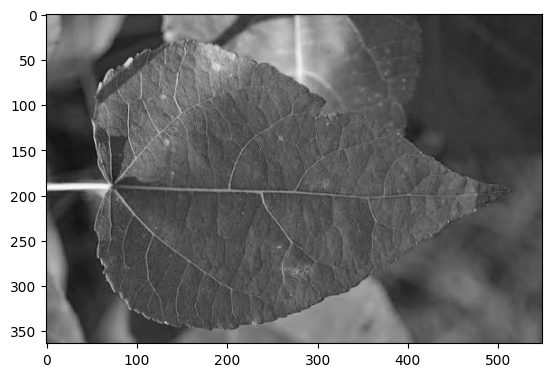

In [6]:
@cuda.jit
def grayscale_2d(src, dst):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
    if tidy < src.shape[0] and tidx < src.shape[1]:
        r = src[tidy, tidx, 0]
        g = src[tidy, tidx, 1]
        b = src[tidy, tidx, 2]
        gray = np.uint8((r + g + b) / 3)
        dst[tidy, tidx, 0] = gray
        dst[tidy, tidx, 1] = gray
        dst[tidy, tidx, 2] = gray


blockSize = (16, 16)
gridSize = (math.ceil(imageWidth / 16), math.ceil(imageHeight / 16))

# first call compiles the kernel, so we do not time it
devInput = cuda.to_device(inputImage)
devOutput = cuda.device_array((imageHeight, imageWidth, 3), np.uint8)
grayscale_2d[gridSize, blockSize](devInput, devOutput)
cuda.synchronize()

start = time.time()
devInput = cuda.to_device(inputImage)
devOutput = cuda.device_array((imageHeight, imageWidth, 3), np.uint8)
grayscale_2d[gridSize, blockSize](devInput, devOutput)
gpuOutput = devOutput.copy_to_host()
gpu2dTime = time.time() - start

print("Grid size:", gridSize, "Block size:", blockSize)
print("GPU 2D time:", gpu2dTime)
print("Speedup 2D:", cpuTime / gpu2dTime)
print("Same result as CPU:", np.array_equal(cpuOutput, gpuOutput))

plt.imsave("gray_gpu_2d.png", gpuOutput)
plt.imshow(gpuOutput)
plt.show()

## 4. Block size vs speedup (1D vs 2D)

4 x 4 | 1D speedup: 7143 | 2D speedup: 7500
8 x 8 | 1D speedup: 13229 | 2D speedup: 14378
16 x 16 | 1D speedup: 14577 | 2D speedup: 14059
32 x 32 | 1D speedup: 13872 | 2D speedup: 12569


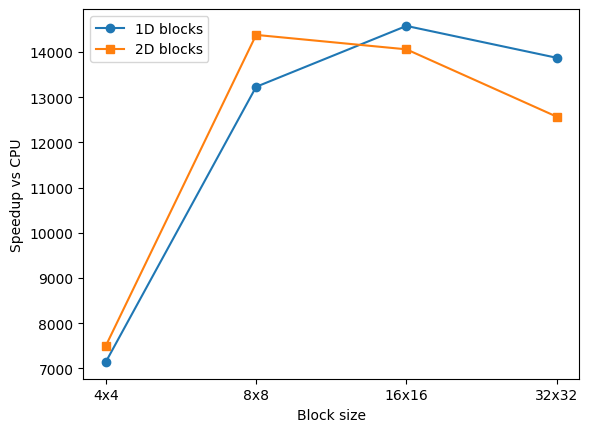

In [7]:
devInput1d = cuda.to_device(flatImage)
devOutput1d = cuda.device_array((pixelCount, 3), np.uint8)
devInput2d = cuda.to_device(inputImage)
devOutput2d = cuda.device_array((imageHeight, imageWidth, 3), np.uint8)

sizes = [4, 8, 16, 32]
speedup1d = []
speedup2d = []

for s in sizes:
    # 1D: s*s threads per block
    blockSize = s * s
    gridSize = math.ceil(pixelCount / blockSize)
    start = time.time()
    for _ in range(50):
        grayscale_1d[gridSize, blockSize](devInput1d, devOutput1d)
    cuda.synchronize()
    time1d = (time.time() - start) / 50

    # 2D: s x s threads per block
    blockSize = (s, s)
    gridSize = (math.ceil(imageWidth / s), math.ceil(imageHeight / s))
    start = time.time()
    for _ in range(50):
        grayscale_2d[gridSize, blockSize](devInput2d, devOutput2d)
    cuda.synchronize()
    time2d = (time.time() - start) / 50

    speedup1d.append(cpuTime / time1d)
    speedup2d.append(cpuTime / time2d)
    print(s, "x", s, "| 1D speedup:", round(speedup1d[-1]), "| 2D speedup:", round(speedup2d[-1]))

labels = [f"{s}x{s}" for s in sizes]
plt.plot(labels, speedup1d, marker="o", label="1D blocks")
plt.plot(labels, speedup2d, marker="s", label="2D blocks")
plt.xlabel("Block size")
plt.ylabel("Speedup vs CPU")
plt.legend()
plt.savefig("blocksize_vs_speedup.png")
plt.show()